In [1]:
import os

os.environ["LD_LIBRARY_PATH"] = (
    "/usr/lib/x86_64-linux-gnu:" +
    os.environ.get("LD_LIBRARY_PATH", "")
)

import onnxruntime as ort
print(ort.get_available_providers())

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']


In [45]:
import os
import cv2
import numpy as np
from fastapi import FastAPI
from fastapi.responses import StreamingResponse
from insightface.app import FaceAnalysis

# ================== CONFIG ==================
RTSP_URL = "rtsp://admin:@192.168.1.69:554/user=admin&password=&channel=1&stream=0.sdp"
EMB_DIR = "data/embeddings"


SIM_THRESHOLD = 0.3

DET_THRESHOLD = 0.6
# ============================================


In [46]:
import onnxruntime as ort
print(ort.get_available_providers())





['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']


In [47]:
files = [f for f in os.listdir(EMB_DIR) if f.endswith(".npy")]
files


['anhht_1.npy', 'anhht_2.npy', 'anhht_3.npy']

In [48]:
from collections import defaultdict

person_embs = defaultdict(list)

for f in files:
    name = f.split("_")[0]      # anhht_1.npy → anhht
    emb = np.load(os.path.join(EMB_DIR, f))

    print(f, emb.shape, np.linalg.norm(emb))

    person_embs[name].append(emb)

person_embs.keys()


anhht_1.npy (512,) 1.0
anhht_2.npy (512,) 0.99999994
anhht_3.npy (512,) 1.0


dict_keys(['anhht'])

In [49]:
db_names = []
db_embs = []

for name, embs in person_embs.items():
    
    embs = np.stack(embs)          # (3, 512)
    proto = embs.mean(axis=0)
    proto = proto / np.linalg.norm(proto)

    db_names.append(name)
    db_embs.append(proto)

db_embs = np.stack(db_embs)

db_names, db_embs.shape


(['anhht'], (1, 512))

In [50]:
print("hello")

hello


In [51]:
face_app = FaceAnalysis(name="buffalo_l")
face_app.prepare(ctx_id=0, det_size=(640, 640))


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/anhht/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 

In [52]:
cap = cv2.VideoCapture(RTSP_URL, cv2.CAP_FFMPEG)
ret, frame = cap.read()

ret, frame.shape


(True, (1296, 2304, 3))

In [53]:
face_app.prepare(
    ctx_id=0,
    det_size=(1280, 1280)
)

set det-size: (1280, 1280)


In [54]:
faces = face_app.get(frame)
print(faces[0]['bbox'])


[485.00336 547.5148  543.0386  611.2805 ]


In [55]:
for f in faces:
    x1, y1, x2, y2 = map(int, f.bbox)
    print(
        "det_score:", f.det_score,
        "face_size:", x2-x1, y2-y1
    
    )


det_score: 0.8914253 face_size: 58 64
det_score: 0.72270304 face_size: 34 44
det_score: 0.6017305 face_size: 32 40


In [56]:
def recognize(face_emb):
    sims = db_embs @ face_emb
    idx = np.argmax(sims)
    return db_names[idx], float(sims[idx])


In [57]:
for f in faces:
    if f.det_score < DET_THRESHOLD:
        continue
    

    emb = f.normed_embedding
    name, score = recognize(emb)

    print(f"[DEBUG] {name} score = {score:.3f}")


[DEBUG] anhht score = 0.510
[DEBUG] anhht score = -0.024
[DEBUG] anhht score = 0.064


(-0.5, 2303.5, 1295.5, -0.5)

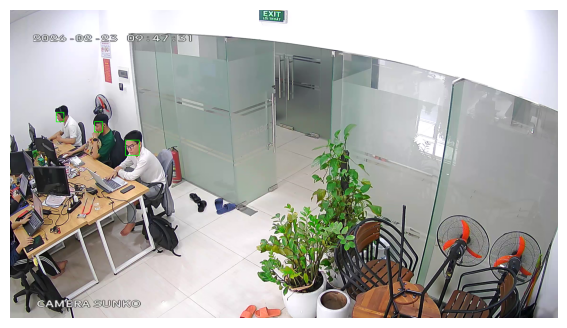

In [58]:
import matplotlib.pyplot as plt

img = frame.copy()

for f in faces:
    x1, y1, x2, y2 = map(int, f.bbox)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.figure(figsize=(8,4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
